In [1]:
import numpy as np
from scripts.visualizer.main import Visualizer
from scripts.helper.make_polygons_bfs import make_polygons
from scripts.helper.triangulate_y_monotone import triangulate_y_monotone
from scripts.helper.triangulate_delaunay import Delaunay
from scripts.helper.load_test import load_polygon

In [2]:
def draw_polygon(polygon: list[tuple[float, float]]) -> None:
    vis = Visualizer()
    vis.add_polygon(polygon, fill=False)
    vis.show()

## Generators

In [3]:
def generate_circle_points(O, R, n=100):
    """
    Funkcja generuje jednostajnie n punktów na okręgu o środku O i promieniu R
    :param O: krotka współrzędnych x, y określająca środek okręgu
    :param R: promień okręgu
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    circle_points = []
    for i in range(n):
        phi = 2 * np.pi * i / n
        x_i, y_i = R * np.cos(phi), R * np.sin(phi)
        circle_points.append((x_i + O[0], y_i + O[1]))
    return circle_points

## Setup

In [4]:
def parition_triangulation(polygon: list[tuple[float, float]]) -> None:
    monotone_polygons = make_polygons(polygon)
    triangulations: list[
        tuple[list[tuple[float, float]], list[tuple[tuple[float, float], tuple[float, float]]]]
    ] = []  # (polygon(x,y), [diagonal((x1,y1), (x2,y2)), ...])
    for monotone_polygon in monotone_polygons:
        triangulations.append((monotone_polygon, triangulate_y_monotone(monotone_polygon)))

    vis = Visualizer()
    vis.add_polygon(polygon, fill=True, color="lightgray")
    for monotone_polygon, diagonals in triangulations:
        vis.add_polygon(monotone_polygon, fill=False, color="red")
        vis.add_line_segment(diagonals, color="purple")
    vis.show()


def parition_triangulation_no_vis(polygon: list[tuple[float, float]]) -> None:
    monotone_polygons = make_polygons(polygon)
    triangulations: list[
        tuple[list[tuple[float, float]], list[tuple[tuple[float, float], tuple[float, float]]]]
    ] = []  # (polygon(x,y), [diagonal((x1,y1), (x2,y2)), ...])
    for monotone_polygon in monotone_polygons:
        triangulations.append((monotone_polygon, triangulate_y_monotone(monotone_polygon)))

In [5]:
def delaunay_triangulation(polygon: list[tuple[float, float]]) -> None:
    Triangulation = Delaunay(polygon)
    Triangulation.get_delaunay_triangulation(visualize=False)


def delaunay_triangulation_no_vis(polygon: list[tuple[float, float]]) -> None:
    Triangulation = Delaunay(polygon)
    Triangulation.get_delaunay_triangulation_no_vis()

## Choose polygon

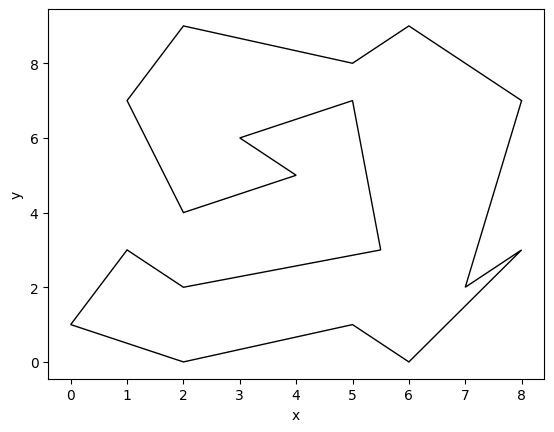

In [6]:
polygon = load_polygon("t0")
# polygon = generate_circle_points((0,0), 10, 2_000)
draw_polygon(polygon)

## Run

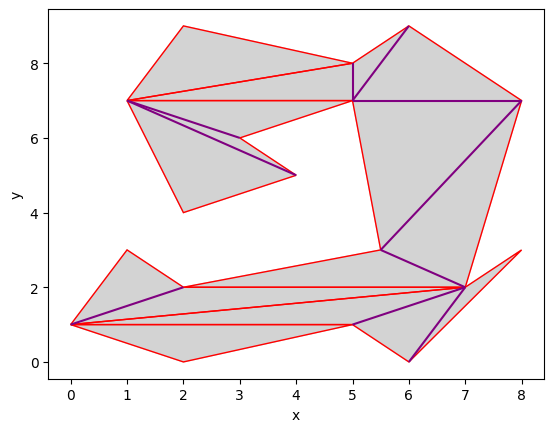

In [7]:
parition_triangulation(polygon)

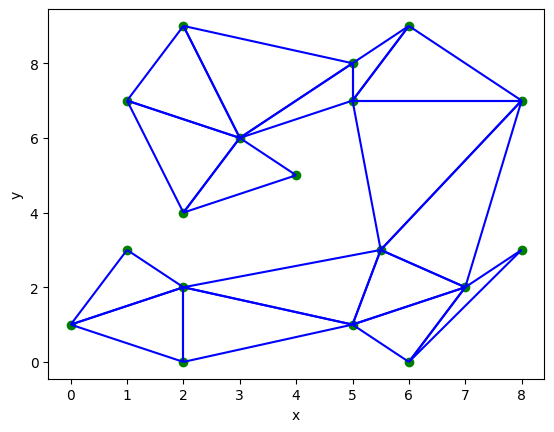

In [8]:
delaunay_triangulation(polygon)

In [9]:
import timeit

N: int = 100
t = timeit.Timer(lambda: parition_triangulation_no_vis(polygon))
print(f"Parition triangulation: {t.timeit(N):.3f}s")
t = timeit.Timer(lambda: delaunay_triangulation_no_vis(polygon))
print(f"Delaunay triangulation: {t.timeit(N):.3f}s")

Parition triangulation: 0.024s
Delaunay triangulation: 0.205s
